# Detectable catalogue of redshigft and corresponding light information (flux)



Note: source frame merger rate density distribution is different from detector frame zs distribution. So you have two options:
- provide mereger rate density (surce frame) or 
- or replace zs (detector frame) sampler (I choose this one). 

In [1]:
# toy model: correlated  zs and light_flux parameter 
# zs can follow SFR (use ler's sfr_madau_dickinson2014 fucntion)
# light_flux should mimic JAGUAR catalogue (Williams et al. 2018) (just toy model; but it needs to be correlated to the zs)

import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import LambdaCDM
from scipy.integrate import cumulative_trapezoid

from ler.gw_source_population import sfr_madau_dickinson2014

N_CATALOGUE = 100_000
Z_MIN = 0.0
Z_MAX = 10.0
RANDOM_SEED = 12345

rng = np.random.default_rng(RANDOM_SEED)
cosmo = LambdaCDM(
    H0=70, Om0=0.3, Ode0=0.7, Tcmb0=0.0, Neff=3.04, m_nu=None, Ob0=0.0
)

# Detector-frame redshift density: SFR(z) * (dVc/dz) / (1 + z).
z_grid = np.linspace(Z_MIN, Z_MAX, 50_000)
p_z = (
    sfr_madau_dickinson2014(z_grid)
    * cosmo.differential_comoving_volume(z_grid).value
    / (1.0 + z_grid)
)
cdf_z = cumulative_trapezoid(p_z, z_grid, initial=0.0)
p_z_pdf = p_z / cdf_z[-1]
cdf_z /= cdf_z[-1]
zs_catalogue = np.interp(rng.random(N_CATALOGUE), cdf_z, z_grid)

# Toy JAGUAR-like broad luminosity population. This omits bandpass,
# K-correction and dust modelling; it is used only to produce a correlated flux.
absolute_ab_magnitude = np.clip(
    rng.normal(loc=-20.0, scale=1.5, size=N_CATALOGUE), -24.0, -14.0
)
apparent_ab_magnitude = absolute_ab_magnitude + cosmo.distmod(zs_catalogue).value
light_flux_catalogue = 10.0 ** ((31.4 - apparent_ab_magnitude) / 2.5)  # nJy
toy_catalogue = dict(zs=zs_catalogue, light_flux=light_flux_catalogue)

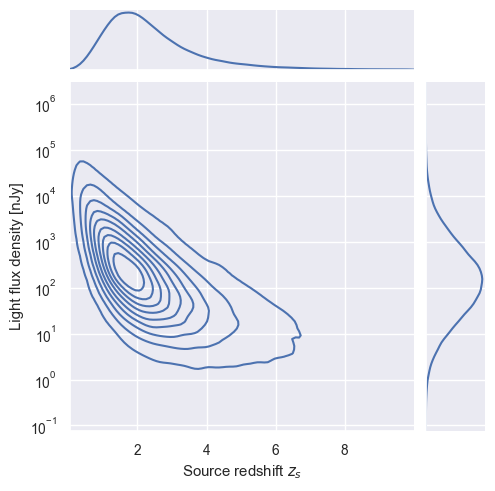

In [2]:
# plot the 2D distribution of zs and light_flux
# this will be later comapre to the detectable catalogue at the end of the simulation
import seaborn as sns

with sns.axes_style("darkgrid"), sns.plotting_context("notebook", font_scale=0.9):
    g = sns.jointplot(
        data=toy_catalogue,
        x="zs",
        y="light_flux",
        kind="kde",
        height=5,
        color=sns.color_palette("deep")[0],
        joint_kws=dict(
            log_scale=(False, True), levels=10, fill=False, cut=0, gridsize=100
        ),
        marginal_kws=dict(fill=False, cut=0, gridsize=100),
    )
    g.set_axis_labels(r"Source redshift $z_s$", r"Light flux density [nJy]")
    plt.show()

## Making custom functions

In [3]:
# ler only needs the zs sampler (1D)
# create point sampler for just zs
# this needs to be numba njit
# the idea is to use this sampler in ler, get the detectable population, then use this zs detectable points to get the light_flux points from the toy catalogue (index and corellation needs to be preserved)

from numba import njit
from ler.utils import FunctionConditioning

# Sample catalogue redshift points with replacement.
@njit
def zs_sampler(size):
    return np.random.choice(zs_catalogue, size=size, replace=True)

@njit
def zs_pdf(zs):
    return np.interp(zs, z_grid, p_z_pdf)

# LeR's lens initialization also needs the PDF associated with the zs sampler.
zs_prior = FunctionConditioning(
    function=None,
    x_array=None,
    create_pdf=zs_pdf,
    create_rvs=zs_sampler,
    callback="rvs",
)


# Sorting once makes the exact catalogue lookup vectorized and O(log N) per zs.
catalogue_sort_indices = np.argsort(zs_catalogue)
zs_catalogue_sorted = zs_catalogue[catalogue_sort_indices]
light_flux_catalogue_sorted = light_flux_catalogue[catalogue_sort_indices]

def light_flux_from_zs(zs):
    """Return the catalogue light flux paired with each sampled zs point."""
    zs_input = np.asarray(zs)
    scalar_input = zs_input.ndim == 0
    zs_array = np.atleast_1d(zs_input)

    indices = np.searchsorted(zs_catalogue_sorted, zs_array)
    matched = indices < N_CATALOGUE
    matched[matched] &= (
        zs_catalogue_sorted[indices[matched]] == zs_array[matched]
    )
    if not np.all(matched):
        raise ValueError("All zs values must be points drawn from zs_catalogue.")

    light_flux = light_flux_catalogue_sorted[indices]
    return light_flux[0] if scalar_input else light_flux.reshape(zs_input.shape)

## ler initialization

In [4]:
# Custom zs and light_flux sampler for toy model needs to be provided in ler initialization

from ler import LeR

ler = LeR(
    # Core setup
    npool=6,
    z_min=Z_MIN,
    z_max=Z_MAX,
    # verbose=False,
    
    # Source priors
    gw_priors=dict(
        zs=zs_prior,
    ),
    gw_priors_params=dict(
        zs=None,
    ),
)


Initializing LeR class...


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ./interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ./interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ./interpolator_json/axis_ratio/rayleigh_0.j

In [5]:
# Select catalogue points with probability proportional to optical depth.
# The catalogue already represents the intrinsic detector-frame p(zs).
tau_catalogue = np.asarray(ler.optical_depth.function(zs_catalogue))
if not np.all(np.isfinite(tau_catalogue)) or np.any(tau_catalogue < 0.0):
    raise ValueError("Catalogue optical depths must be finite and non-negative.")
if tau_catalogue.sum() <= 0.0:
    raise ValueError("At least one catalogue optical depth must be positive.")
zs_sl_weights = tau_catalogue / tau_catalogue.sum()

# Weighted np.random.choice (p=) is not supported by the installed Numba.
def zs_sl_sampler(size):
    return np.random.choice(
        zs_catalogue, size=size, replace=True, p=zs_sl_weights
    )

zs_sl_prior = FunctionConditioning(
    create_rvs=zs_sl_sampler,
    callback="rvs",
)
ler.zs_sl = zs_sl_prior

using user provided custom zs_sl class/object of type ler.utils.FunctionConditioning


## Testing custom functions 

In [6]:
# test ler.zs.rvs 
# get zs points and corresponding light_flux points from the toy catalogue
# plot it
N_TEST = 20_000
zs_test = ler.zs.rvs(N_TEST)
light_flux_test = light_flux_from_zs(zs_test)

assert zs_test.shape == light_flux_test.shape == (N_TEST,)
assert np.all(np.isfinite(light_flux_test))
assert np.all(light_flux_test > 0.0)
catalogue_check_indices = np.array([0, N_CATALOGUE // 3, N_CATALOGUE - 1])
np.testing.assert_array_equal(
    light_flux_from_zs(zs_catalogue[catalogue_check_indices]),
    light_flux_catalogue[catalogue_check_indices],
)

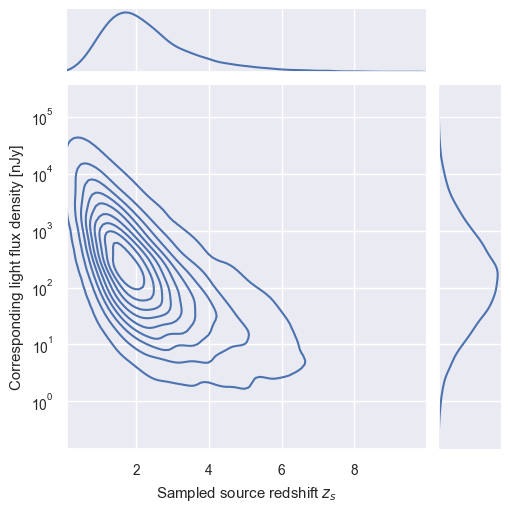

In [7]:
# Plot the sampled redshifts and their corresponding catalogue fluxes.
import seaborn as sns

with sns.axes_style("darkgrid"), sns.plotting_context("notebook", font_scale=0.9):
    g_test = sns.jointplot(
        x=zs_test,
        y=light_flux_test,
        kind="kde",
        height=5,
        color=sns.color_palette("deep")[0],
        joint_kws=dict(
            log_scale=(False, True), levels=10, fill=False, cut=0, gridsize=100
        ),
        marginal_kws=dict(fill=False, cut=0, gridsize=100),
    )
    g_test.set_axis_labels(
        r"Sampled source redshift $z_s$",
        r"Corresponding light flux density [nJy]",
    )
    plt.show()

## Replace P(zs|SL) with custom function

In [5]:
from ler.utils import FunctionConditioning

# Select catalogue points with probability proportional to optical depth.
# The catalogue already represents the intrinsic detector-frame p(zs).
tau_catalogue = np.asarray(ler.optical_depth.function(zs_catalogue))

# Check for valid optical depth values
if not np.all(np.isfinite(tau_catalogue)) or np.any(tau_catalogue < 0.0):
    raise ValueError("Catalogue optical depths must be finite and non-negative.")
if tau_catalogue.sum() <= 0.0:
    raise ValueError("At least one catalogue optical depth must be positive.")

# Calculate weights proportional to optical depth
zs_sl_weights = tau_catalogue / tau_catalogue.sum()

# Weighted np.random.choice (p=) is not supported by the installed Numba, 
# so we define this as a standard Python function.
def zs_sl_sampler(size):
    return np.random.choice(
        zs_catalogue, size=size, replace=True, p=zs_sl_weights
    )

# Create the custom prior object
zs_sl_prior = FunctionConditioning(
    create_rvs=zs_sl_sampler,
    callback="rvs",
)

# Replace the default zs_sl object in the initialized LeR instance
ler.zs_sl = zs_sl_prior

using user provided custom zs_sl class/object of type ler.utils.FunctionConditioning


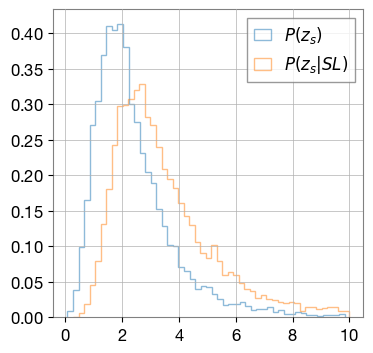

In [9]:
zs_test = ler.zs(10000)
zs_sl_test = ler.zs_sl(10000)

# plot hist
plt.figure(figsize=(4, 4))
plt.hist(zs_test, bins=50, alpha=0.5, label=r"$P(z_s)$", density=True, histtype="step")
plt.hist(zs_sl_test, bins=50, alpha=0.5, label=r"$P(z_s|SL)$", density=True, histtype="step")
plt.legend()
plt.show()


## Selecting detectable catalogue

In [10]:
# njit compilation takes some time initially
lensed_params = ler.lensed_cbc_statistics(size=100000, batch_size=100000, resume=False, output_jsonfile=False)

lensed params will not be saved to file (output_jsonfile=None/False)
Batch no. 1
sampling lensed params...
sampling lens parameters with epl_shear_sl_parameters_rvs...
computing image properties using ler's epl+shear (analytical, njit) solver...
Invalid sample found. Resampling 238 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
computing image properties using ler's epl+shear (analytical, njit) solver...
Invalid sample found. Resampling 1 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
computing image properties using ler's epl+shear (analytical, njit) solver...
calculating pdet...


In [11]:
# include other useful parameters in the output dictionary.
# It is omitted by default to save runtime and memory.
# For theta_E, n_images, mass_1, mass_2, luminosity_distance:
lensed_params = ler.recover_redundant_parameters(lensed_params)
# For effective_luminosity_distance, effective_geocent_time, effective_phase, effective_ra, effective_dec:
lensed_params = ler.produce_effective_params(lensed_params)

In [ ]:
rate_lensed, lensed_param_detectable = ler.lensed_rate(
    lensed_param=lensed_params,
    pdet_threshold=[0.5, 0.5],
    num_img=[1, 1],
    output_jsonfile='zs_light_lens_param_det.json',
    nan_to_num=True,
    pdet_type='boolean',
)

Using provided lensed_param dict...
total lensed rate (yr^-1): 0.16663488471161308
number of simulated lensed detectable events: 149
number of simulated all lensed events: 100000
storing detectable params in ./ler_data/zs_light_lens_param.json


In [15]:
# get zs and corresponding light_flux
zs_det = lensed_param_detectable['zs']
light_flux_det = light_flux_from_zs(zs_det)
light_flux_det[:10]

array([22644.84084029,    30.06011327,   174.27863176,
          44.37311535,  1749.94444113,  2458.08576664,
          41.50464776,   191.43586648,  1576.84539709,
         200.04482329])

## Selecting more detectable events

In [16]:
# Sample until we have at least 1,000 detectable lensed events
# the choice of size, batch_size and stopping_criteria here is to run the test quickly. If you are comparing with the unlensed results, you should use the same size, batch_size and stopping_criteria as the unlensed case.
detectable_rate_lensed, lensed_param_detectable_n = ler.selecting_n_lensed_detectable_events(
    size=1000,                           # Target number of detectable events
    batch_size=100000,                    # Events per batch
    stopping_criteria=None,              # No stopping criteria (sample until size is reached)
    pdet_threshold=[0.5, 0.5],           # Detection thresholds for images
    num_img=[1, 1],                      # Number of images required per threshold
    resume=False,                        # Resume from previous state if available
    output_jsonfile='zs_light_lens_param_det.json',
    meta_data_file='meta_zs_light_lens_param.json',
    pdet_type='boolean',
    trim_to_size=False,
)

print(f"\n=== Lensed N-Event Sampling Results ===")
print(f"Detectable event rate: {detectable_rate_lensed:.4e} events per year")
print(f"Total detectable events collected: {len(lensed_param_detectable_n['zs'])}")

stopping criteria not set. sample collection will stop when number of detectable events exceeds the specified size.
removing ./ler_data/zs_light_lens_param_det.json if it exists
removing ./ler_data/meta_zs_light_lens_param.json if it exists
collected number of detectable events =  0
collected number of detectable events (batch) =  172
collected number of detectable events (cumulative) =  172
total number of events =  100000
batch rate (yr^-1): 0.19235704812347282
total rate (yr^-1): 0.19235704812347282
collected number of detectable events (batch) =  172
collected number of detectable events (cumulative) =  344
total number of events =  200000
batch rate (yr^-1): 0.19235704812347282
total rate (yr^-1): 0.19235704812347282
collected number of detectable events (batch) =  138
collected number of detectable events (cumulative) =  482
total number of events =  300000
batch rate (yr^-1): 0.15433298047115843
total rate (yr^-1): 0.17968235890603468
collected number of detectable events (batch

In [17]:
# get zs and corresponding light_flux
zs_det = lensed_param_detectable_n['zs']
light_flux_det = light_flux_from_zs(zs_det)
light_flux_det[:10]

array([1591.96634984,  795.86120991,  308.77738027,
       3221.47088689,  185.3948736 ,  109.79426083,
         45.87111213,  143.03737722,  288.17288368,
       1204.97856255])

## Comparison of intrinsic and detectable (lensed) light flux distributions

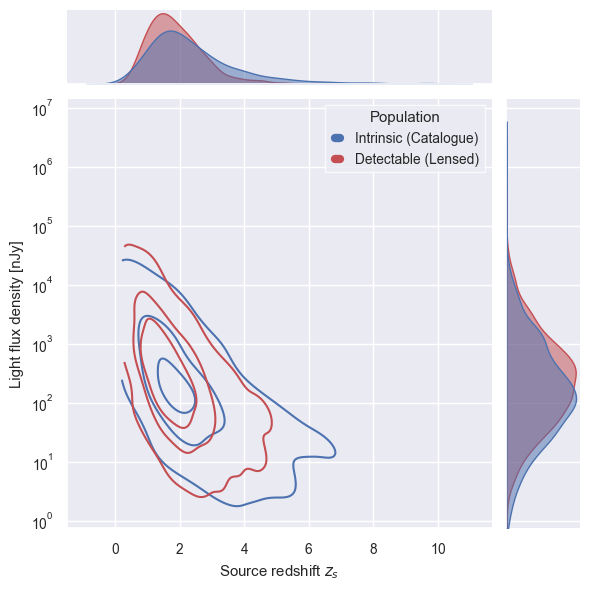

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create DataFrames for both populations
# Downsample the intrinsic population to 1000 events to match the detectable population
df_intrinsic = pd.DataFrame({
    'zs': toy_catalogue['zs'],
    'light_flux': toy_catalogue['light_flux'],
    'Population': 'Intrinsic (Catalogue)'
}).sample(n=1000, random_state=42)

df_detectable = pd.DataFrame({
    'zs': zs_det,
    'light_flux': light_flux_det,
    'Population': 'Detectable (Lensed)'
})

# 2. Combine them into a single DataFrame
df_combined = pd.concat([df_intrinsic, df_detectable], ignore_index=True)

# 3. Plot the joint distribution
with sns.axes_style("darkgrid"), sns.plotting_context("notebook", font_scale=0.9):
    g = sns.jointplot(
        data=df_combined,
        x="zs",
        y="light_flux",
        hue="Population",
        kind="kde",
        height=6,
        palette=["#4C72B0", "#C44E52"],  # Distinct blue and red colors
        joint_kws=dict(
            log_scale=(False, True), 
            levels=4, 
            fill=False, 
            cut=0
        ),
        marginal_kws=dict(
            fill=True, 
            common_norm=False,  # Normalizes marginals independently so both are visible
            alpha=0.5
        ),
    )
    g.set_axis_labels(r"Source redshift $z_s$", r"Light flux density [nJy]")
    plt.show()